In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as snn

In [8]:
rating=pd.read_csv('ratings.csv')
rating.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [9]:
movie=pd.read_csv('movies.csv')
movie

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
9737,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy
9738,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy
9739,193585,Flint (2017),Drama
9740,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation


In [10]:
n_user=rating.userId.unique().shape[0]
n_user

610

In [11]:
n_movie=rating.movieId.unique().shape[0]
n_movie

9724

In [12]:
rating.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [13]:
Rating=rating.pivot(index='userId',columns='movieId',values='rating').fillna(0)
Rating

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,2.5,0.0,0.0,0.0,0.0,0.0,2.5,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
607,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
608,2.5,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
from surprise.model_selection import cross_validate
from surprise import Dataset,SVD,Reader
reader=Reader()

In [15]:
data=Dataset.load_from_df(rating[['userId','movieId','rating']],reader)
svd=SVD()
cross_validate(svd,data,measures=["rmse", "mae"],cv=3,verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 3 split(s).

                  Fold 1  Fold 2  Fold 3  Mean    Std     
RMSE (testset)    0.8859  0.8809  0.8764  0.8811  0.0039  
MAE (testset)     0.6794  0.6769  0.6757  0.6773  0.0015  
Fit time          2.00    1.33    1.18    1.50    0.35    
Test time         0.77    0.31    0.24    0.44    0.24    


{'test_rmse': array([0.8858812 , 0.88088948, 0.87641184]),
 'test_mae': array([0.67939004, 0.67687372, 0.67570614]),
 'fit_time': (1.9976353645324707, 1.331162452697754, 1.1832187175750732),
 'test_time': (0.7745866775512695, 0.30739760398864746, 0.23533225059509277)}

In [23]:
rating_1=rating[(rating['userId']==1) & (rating['rating']==4)]
rating_1=rating_1.set_index('movieId')
rating_1=rating_1.join(movie)['title']
rating_1.head()

movieId
1                                         Jumanji (1995)
3                               Waiting to Exhale (1995)
6                                         Sabrina (1995)
110                                Jupiter's Wife (1994)
235    Mary Shelley's Frankenstein (Frankenstein) (1994)
Name: title, dtype: object

In [25]:
user_1=movie.copy()
user_1=user_1.reset_index()
data=Dataset.load_from_df(rating[["userId","movieId","rating"]],reader)
traindata=data.build_full_trainset()
svd.fit(traindata)

In [27]:
user_1['estimate_score']=user_1['movieId'].apply(lambda x: svd.predict(1,x).est)
user_1=user_1.drop(["movieId",'genres','index'],axis=1)
user_1=user_1.sort_values('estimate_score',ascending=False)
print(user_1.head())

                                           title  estimate_score
3413            Hedwig and the Angry Inch (2000)             5.0
2372                      Green Mile, The (1999)             5.0
1730  Life Is Beautiful (La Vita è bella) (1997)             5.0
686                           Rear Window (1954)             5.0
922               Godfather: Part II, The (1974)             5.0


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
data={
    'age':[18,22,25,30,35],
    'mark':[75,82,78,90,88],
}
df=pd.DataFrame(data)


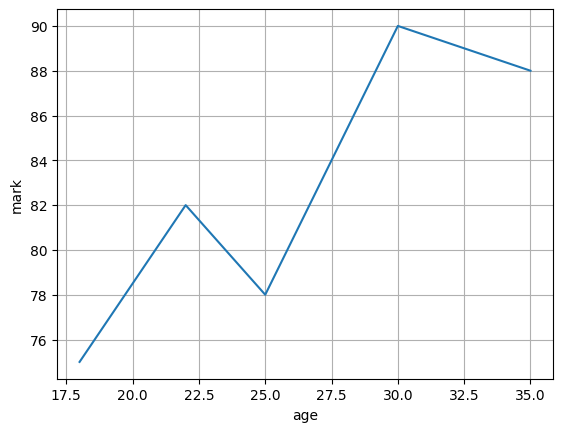

In [8]:
plt.figure()
plt.plot(df['age'],df['mark'])
plt.xlabel("age")
plt.ylabel('mark')
plt.grid(True)
plt.show()